In [1]:
!pip install opencv-python numpy matplotlib scikit-image scikit-learn medpy

Read dataset & preprocessing 


Found 4932 images in 'train' set.


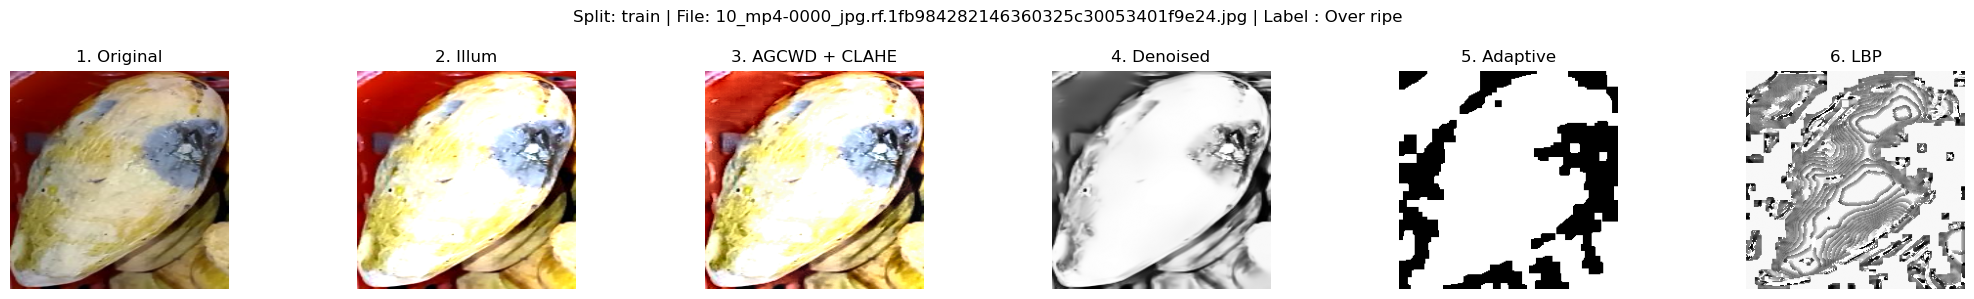

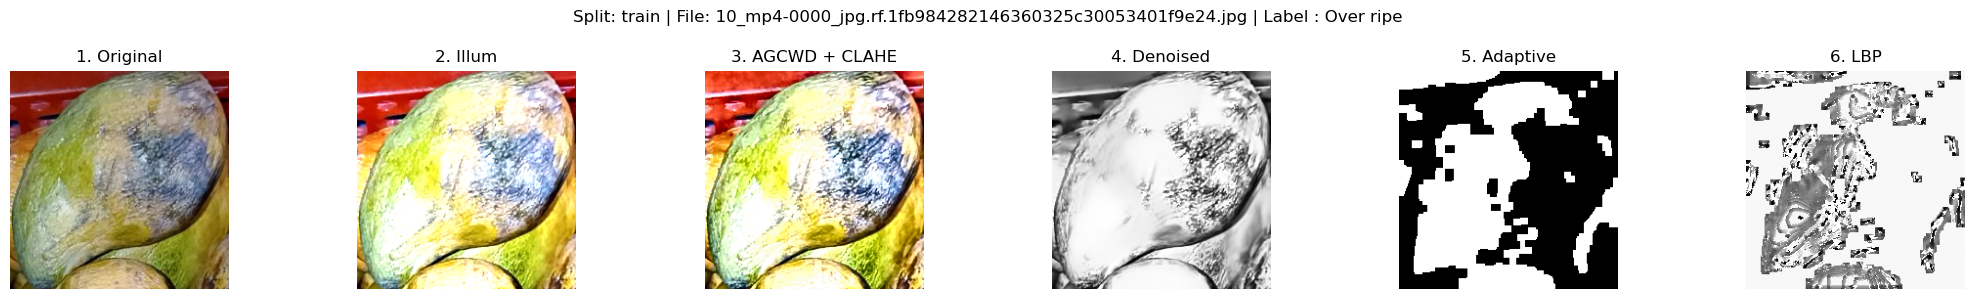

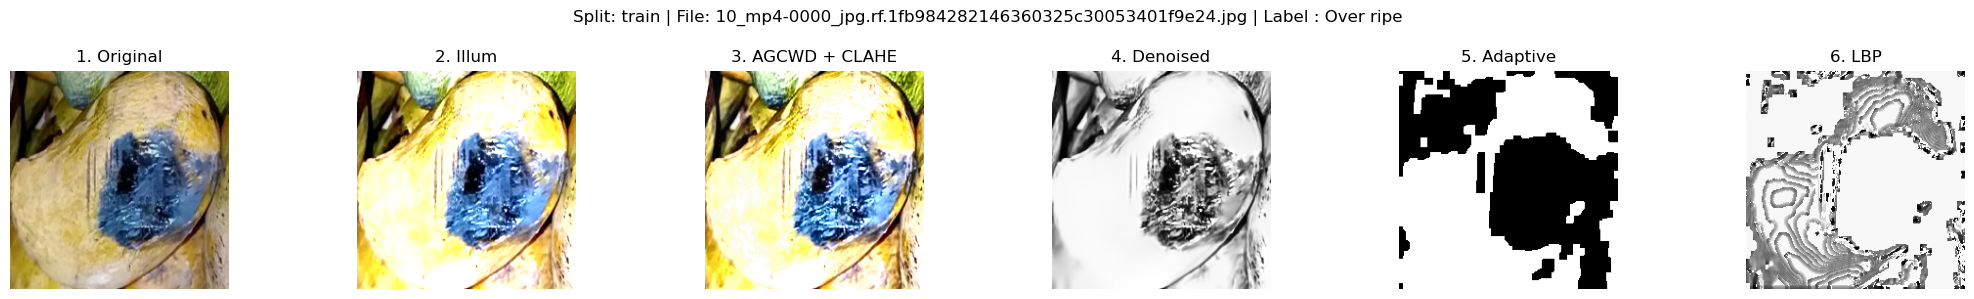

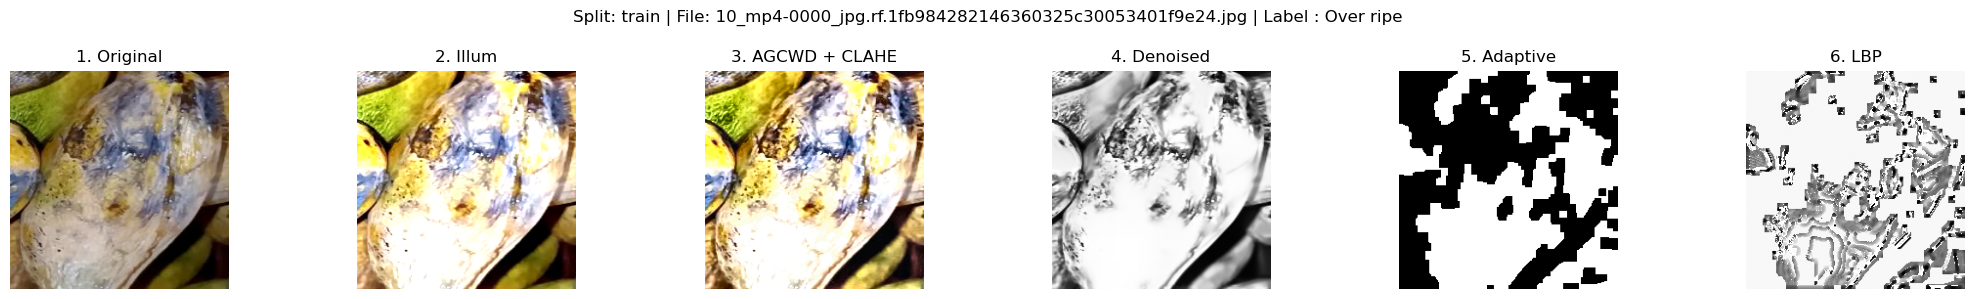

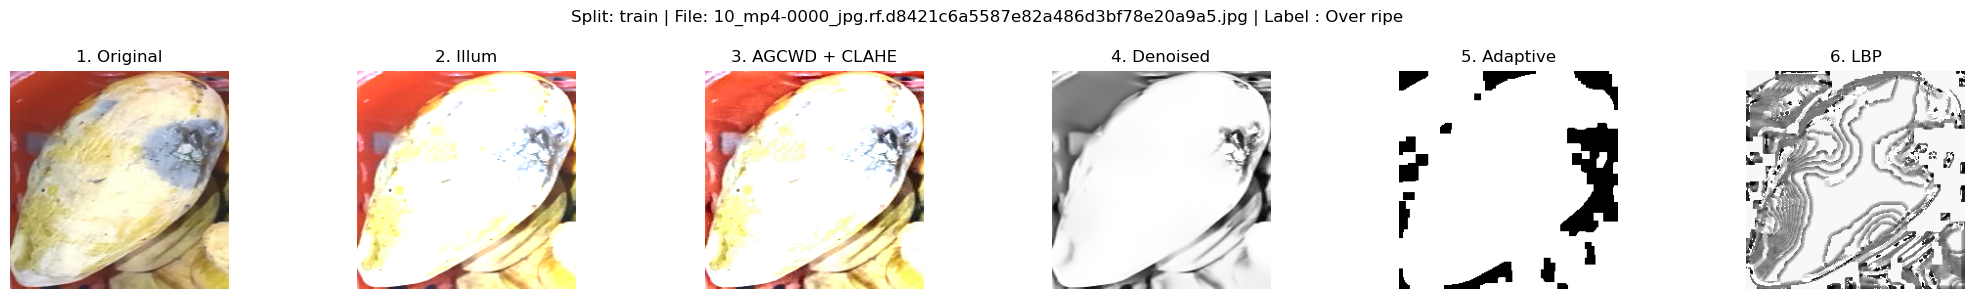


Found 453 images in 'valid' set.

Found 228 images in 'test' set.
Training: (53083, 34) (53083,)
Validation: (4791, 34) (4791,)
Testing: (2632, 34) (2632,)


In [1]:
%matplotlib inline
import xml.etree.ElementTree as ET
from pathlib import Path
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from skimage.feature import local_binary_pattern
from medpy.filter.smoothing import anisotropic_diffusion

def AGCWD(channel, alpha=0.8):
    hist = cv.calcHist([channel], [0], None, [256], [0,256])
    hist = hist.flatten()
    pdf = hist / np.sum(hist)
    pdf_weighted = pdf ** alpha
    pdf_weighted = pdf_weighted / np.sum(pdf_weighted)
    cdf = np.cumsum(pdf_weighted)
    gamma = 1 - cdf
    LUT = np.zeros(256)
    for i in range(256):
        LUT[i] = 255 * ((i/255) ** gamma[i])
    LUT = np.clip(LUT,0,255).astype(np.uint8)
    enhanced = cv.LUT(channel,LUT)
    return enhanced

DATASET_PATH = Path("./MangoDataset")
SPLITS = ["train", "valid", "test"]

X_train = []
y_train = []

X_valid = []
y_valid = []

X_test = []
y_test = []

display_count = 0 

for split in SPLITS:
    folder = DATASET_PATH / split
    if not folder.exists():
        print(f"Skipping missing folder: {folder}")
        continue
    image_files = list(folder.glob("*.jpg"))
    print(f"\nFound {len(image_files)} images in '{split}' set.")

    for img_path in image_files:
        img = cv.imread(str(img_path))
        if img is None:
            continue

        img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

        xml_path = img_path.with_suffix(".xml")

        if xml_path.exists():
        
            tree = ET.parse(xml_path)
            root = tree.getroot()
        
            for obj in root.findall("object"):
        
                label = obj.find("name").text
        
                b = obj.find("bndbox")
        
                xmin = int(b.find("xmin").text)
                ymin = int(b.find("ymin").text)
                xmax = int(b.find("xmax").text)
                ymax = int(b.find("ymax").text)
        
                crop = img[ymin:ymax, xmin:xmax]
        
                if crop.size == 0:
                    continue
        
                crop = cv.resize(crop, (224, 224))

                crop_rgb = cv.cvtColor(crop, cv.COLOR_BGR2RGB)

                # Shadow & Illumination Correction
                blur_ambient = cv.GaussianBlur(crop, (31, 31), 0)
                illum_corrected = cv.addWeighted(crop, 1.8, blur_ambient, -0.2, 0)
            
                # LAB Colour Space 
                lab = cv.cvtColor(illum_corrected, cv.COLOR_BGR2LAB)
                L, A, B = cv.split(lab)
            
                # Adaptive Gamma Correction (AGCWD)
                L_enhanced = AGCWD(L)

                # CLAHE
                clahe = cv.createCLAHE(
                    clipLimit=3.0,
                    tileGridSize=(12, 12)
                )
                
                L_clahe = clahe.apply(L_enhanced)
                
                # Merge LAB channels
                lab_enhanced = cv.merge([L_clahe, A, B])
                
                # Convert back to BGR
                enhanced_bgr = cv.cvtColor(
                    lab_enhanced,
                    cv.COLOR_LAB2BGR
                )
                
                enhanced_rgb = cv.cvtColor(
                    enhanced_bgr,
                    cv.COLOR_BGR2RGB
                )

                gray = cv.cvtColor(enhanced_bgr, cv.COLOR_BGR2GRAY)
                
                # Non-local Means 
                denoised = cv.fastNlMeansDenoising(
                    gray,
                    None,
                    h=15,
                    templateWindowSize=12,
                    searchWindowSize=31
                )
            
                # Adptive Guassian Thresholding
                adaptive_mask = cv.adaptiveThreshold(denoised,255,cv.ADAPTIVE_THRESH_GAUSSIAN_C,cv.THRESH_BINARY,15,5)

                # Morphological procesing
                kernel = np.ones((7,7), np.uint8)

                adaptive_mask = cv.morphologyEx(
                    adaptive_mask,
                    cv.MORPH_OPEN,
                    kernel
                )
                
                adaptive_mask = cv.morphologyEx(
                    adaptive_mask,
                    cv.MORPH_CLOSE,
                    kernel
                )

                # Local Feature / Edge Extraction
                radius = 4
            
                n_points = 8 * radius
                    
                segmented = cv.bitwise_and(
                    denoised,
                    denoised,
                    mask=adaptive_mask
                )
                
                lbp = local_binary_pattern(
                    segmented,
                    n_points,
                    radius,
                    method="uniform"
                )

                n_bins = n_points + 2

                hist, _ = np.histogram(lbp.ravel(),bins=n_bins,range=(0, n_bins),density=True)
                
                if split == "train":
                    X_train.append(hist)
                    y_train.append(label)
                
                elif split == "valid":
                    X_valid.append(hist)
                    y_valid.append(label)
                
                elif split == "test":
                    X_test.append(hist)
                    y_test.append(label)

                if display_count < 5:
                    fig, axes = plt.subplots(1, 6, figsize=(21,3))
                
                    axes[0].imshow(crop_rgb)
                    axes[0].set_title("1. Original")
                    axes[1].imshow(cv.cvtColor(illum_corrected, cv.COLOR_BGR2RGB))
                    axes[1].set_title("2. Illum")
                    axes[2].imshow(enhanced_rgb)
                    axes[2].set_title("3. AGCWD + CLAHE")
                    axes[3].imshow(denoised, cmap="gray")
                    axes[3].set_title("4. Denoised")
                    axes[4].imshow(adaptive_mask, cmap="gray")
                    axes[4].set_title("5. Adaptive")
                    axes[5].imshow(lbp, cmap="gray")
                    axes[5].set_title("6. LBP")
                
                    for ax in axes:
                        ax.axis("off")
                
                    plt.suptitle(f"Split: {split} | File: {img_path.name} | Label : {label}")
                    plt.tight_layout()
                    plt.show()

                    display_count += 1

X_train = np.array(X_train)
y_train = np.array(y_train)

X_valid = np.array(X_valid)
y_valid = np.array(y_valid)

X_test = np.array(X_test)
y_test = np.array(y_test)
                
print("Training:", X_train.shape, y_train.shape)
print("Validation:", X_valid.shape, y_valid.shape)
print("Testing:", X_test.shape, y_test.shape)

Train

In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)
X_test_scaled = scaler.transform(X_test)

# Train SVM
svm_model = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    probability=True,
    random_state=42
)

svm_model.fit(X_train_scaled, y_train)

train_pred = svm_model.predict(X_train_scaled)
valid_pred = svm_model.predict(X_valid_scaled)
test_pred = svm_model.predict(X_test_scaled)

print("Training Accuracy:", accuracy_score(y_train, train_pred))
print("Validation Accuracy:",accuracy_score(y_valid, valid_pred))
print("Testing Accuracy:", accuracy_score(y_test, test_pred))

Training Accuracy: 0.9605146657121866
Validation Accuracy: 0.9653517011062409
Testing Accuracy: 0.9684650455927052


In [3]:
from sklearn.metrics import classification_report

print(classification_report(y_test, test_pred))

              precision    recall  f1-score   support

   Over ripe       0.96      0.97      0.97       413
        Ripe       0.96      0.98      0.97      1113
      Unripe       0.98      0.96      0.97      1106

    accuracy                           0.97      2632
   macro avg       0.97      0.97      0.97      2632
weighted avg       0.97      0.97      0.97      2632



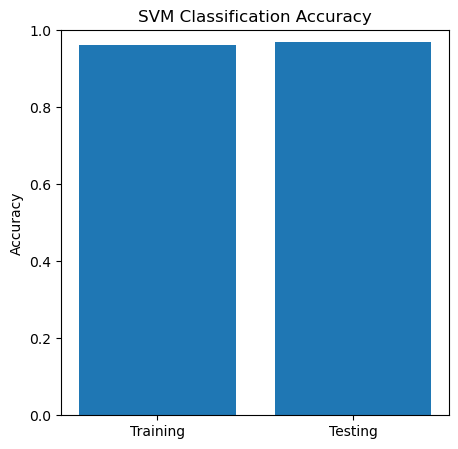

In [4]:
import matplotlib.pyplot as plt

train_acc = accuracy_score(y_train, train_pred)
test_acc = accuracy_score(y_test, test_pred)

plt.figure(figsize=(5,5))

plt.bar(
    ["Training", "Testing"],
    [train_acc, test_acc]
)

plt.ylim(0,1)
plt.ylabel("Accuracy")
plt.title("SVM Classification Accuracy")

plt.show()

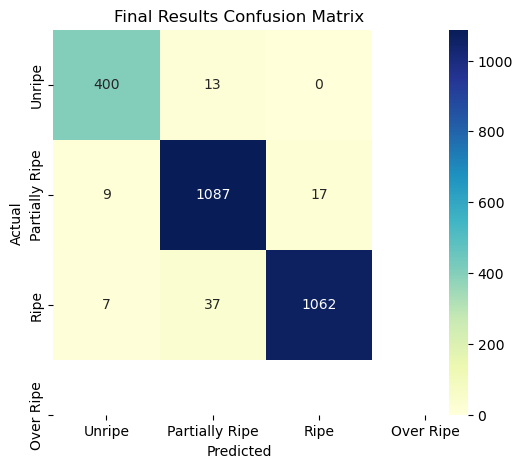

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, test_pred)
labels = ["Unripe", "Partially Ripe", "Ripe", "Over Ripe"]

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="YlGnBu",
    xticklabels=labels,
    yticklabels=labels
)

plt.title("Final Results Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

In [6]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
 
accuracy = accuracy_score(y_test, test_pred)
precision = precision_score(y_test, test_pred, average="weighted")
recall = recall_score(y_test, test_pred, average="weighted")
f1 = f1_score(y_test, test_pred, average="weighted")

print("----- Final Summary Metrics -----")
print(f"Accuracy : {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall   : {recall:.3f}")
print(f"F1 Score : {f1:.3f}")

----- Final Summary Metrics -----
Accuracy : 0.968
Precision: 0.969
Recall   : 0.968
F1 Score : 0.968
